In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix
)

## Classification (Multi-Class): Iris Dataset

In [3]:
# Load the Dataset
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target

print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [4]:
# Split the Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=1

)

In [5]:
X_train[:10]

array([[6.1, 3. , 4.6, 1.4],
       [7.7, 3. , 6.1, 2.3],
       [5.6, 2.5, 3.9, 1.1],
       [6.4, 2.8, 5.6, 2.1],
       [5.8, 2.8, 5.1, 2.4],
       [5.3, 3.7, 1.5, 0.2],
       [5.5, 2.3, 4. , 1.3],
       [5.2, 3.4, 1.4, 0.2],
       [6.5, 2.8, 4.6, 1.5],
       [6.7, 2.5, 5.8, 1.8]])

In [6]:
y_train[:10]

array([1, 2, 1, 2, 2, 0, 1, 0, 1, 2])

In [7]:
for i, value in enumerate (iris.target_names):
    print(i, value)

0 setosa
1 versicolor
2 virginica


In [8]:
len(X_train), len(y_train)

(120, 120)

In [9]:
# Train a Classifier. Let's use a Logistic Regression

from sklearn.linear_model import LogisticRegression

clf_model = LogisticRegression(max_iter=200)
clf_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [10]:
# Evaluate the Classifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

y_pred = clf_model.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9666666666666667


In [12]:
print(y_pred)
print(y_test)

[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 2 0 2 1 0 0 1 2]
[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2]


In [13]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.92      0.96        13
           2       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [14]:
# For Class B: Precision_B = TruePositives_B / (TruePositives_B + FalsePositives
# For Class C: Precision_C = TruePositives_C / (TruePositives_C + FalsePositives
# for our problem, if we should calculate by hand:
print(6/(1+0))
print((6/7)*100)

6.0
85.71428571428571


In [15]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]


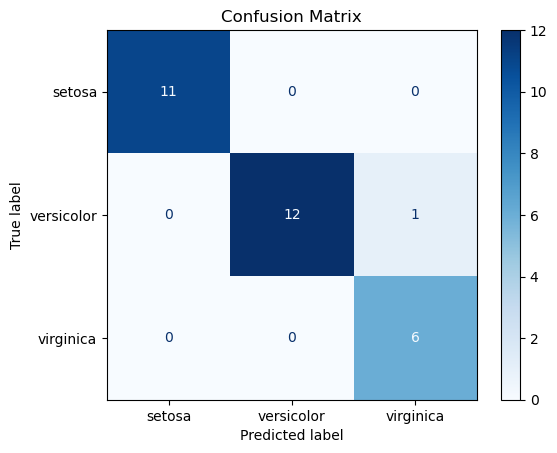

In [16]:
import matplotlib.pyplot as plt
cm_display = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=iris.target_names)
cm_display.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
# plt.colorbar()
plt.show()

In [17]:
# The confusion matrix shows how well your model performed in terms of ac
# For a 3-class problem like the Iris dataset
# from the above, each value means:
# Diagonal = correct predictions (model got it right)
# Off-diagonal = misclassifications

# accuracy = (TP+TN)/(TP+TN)+(FP+FN)
# P = TP/(TP+FP)

In [18]:
len(X_test)

30

In [19]:
print(y_pred)
print(y_test)

[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 2 0 2 1 0 0 1 2]
[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2]


### Creating a Prediction Function Let’s build a function that: Accepts 4 flower measurements Predicts the species name

In [22]:
def predict_flower(sepal_length, sepal_width, petal_length, petal_width):
    sample = [[sepal_length, sepal_width, petal_length, petal_width]]
    
    # Predict
    pred = clf_model.predict(sample)[0]
    
    species = iris.target_names
    prediction = f'The species of flower is {species[pred]}'
    
    return prediction

In [23]:
print(predict_flower(5.1, 3.5, 1.4, 0.2))

The species of flower is setosa


In [24]:
print(predict_flower(6.0, 3.0, 4.8, 1.8))

The species of flower is virginica


In [25]:
clf_model.predict([[5.1, 3.5, 1.4, 0.2]])

array([0])